In [26]:
import numpy as np
import pandas as pd
import math
import heapq
import matplotlib.pyplot as plt
from decimal import Decimal
floaterr = 1.0e-8

In [27]:
a = pd.read_csv("./datasets/a280.csv")
# a = pd.read_csv("./minidatasets/minitsp.csv")
points = np.array(a[['x','y']])
inputsize = len(points)

In [28]:
# distance matrix 만들기
diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]
distance_matrix = np.sqrt(np.sum(diff ** 2, axis=-1))

In [29]:
# MST 찾기( 프림 알고리즘 사용)
visited = [False] * len(points)
minheap = []
mstgraph = np.full( ( inputsize, inputsize ), np.inf)

# 0 추가
for x in range(inputsize):
    heapq.heappush(minheap, ( distance_matrix[0][x] , 0, x ) )
visited[ 0 ] = True

while minheap:
    Weight, From, To = heapq.heappop( minheap )
    if not visited[To]:
        visited[To] = True
        mstgraph[ From, To ] = Weight
        mstgraph[ To, From ] = Weight
        for x in range(inputsize):
            next_to, next_weight = x, distance_matrix[To][x]
            if not visited[ next_to ]:
                heapq.heappush( minheap, ( next_weight, To, next_to ) )

In [30]:
# 홀수 degree 찾기
oddmat = np.full( ( inputsize, inputsize ), np.inf)

finite_mask = np.isfinite(mstgraph)              # inf가 아닌 값은 True
finite_count_per_row = finite_mask.sum(axis=1) # 각 행마다 inf가 아닌 값의 개수
odd_rows = np.where(finite_count_per_row % 2 == 1)[0]  # 개수가 홀수인 행 인덱스

print(odd_rows.tolist())

[0, 1, 4, 5, 7, 8, 12, 14, 15, 16, 17, 18, 19, 20, 31, 33, 34, 43, 44, 45, 46, 47, 48, 50, 51, 52, 53, 54, 55, 57, 61, 62, 64, 66, 68, 74, 75, 77, 78, 80, 82, 83, 84, 88, 92, 93, 95, 96, 97, 98, 100, 103, 105, 106, 108, 111, 113, 115, 124, 127, 129, 130, 131, 133, 134, 135, 136, 137, 141, 142, 143, 145, 146, 147, 149, 150, 168, 171, 173, 177, 178, 180, 187, 188, 191, 192, 193, 200, 207, 220, 230, 231, 232, 234, 235, 236, 239, 240, 242, 244, 245, 247, 249, 255, 263, 264, 266, 267, 268, 269, 275, 277, 278, 279]


In [31]:
next_id = len(distance_matrix)

In [32]:
class blossom:
    def __init__(self, G, Id, nodes=None, edges=None):
        self.Graph = G
        self.Id = Id
        self.Dual = Decimal(0)
        self.Matching = None
        self.Nodes = [] # 블라썸에 포함된 노드들
        self.Edges = [] # 블라썸 원래 노드들
        
        self.Visited = False
        self.Label = None
        self.parent = None
        self.path = [] # root 부터 여기까지 온 경로 ( 노드들 )
        self.root = None
        self.base = None

        if nodes != None:
            self.Nodes += nodes
        if edges != None:
            self.Edges += edges
        
    def is_blossom(self):
        if len(self.Nodes) >= 3:
            return True
        return False
        
    def add_node(self, v):
        self.Nodes.append(v)
    def add_edge(self, e):
        self.Edges.append(e)
        
    def distance(self, v):
        return self.Graph.distance(self,v)
        
    def slack(self, v):
        return self.Graph.slack(self,v)
        
    def labeling(self): # label visited
        if self.parent == None:
            self.Label = True
        if self.Label != None:
            return
        self.Label = not self.parent.Label
    
    def is_containning(self, node):
        if self.Nodes == []: # base case
            if self == node:
                return True
        
        for x in self.Nodes:
            if x.is_containning(node):
                return True
        return False

In [33]:
# 모든 노드는 블라썸 노드로 생각 할 수 있다.
# 사이즈가 1 이면 일반노드, 3 이상의 홀수 노드이면 블라썸이 되는 것.
# 이떄, 
# 1. 블라썸은 자기에 포함된 노드를 가지고 있어야한다.
# 2. 엣지도 알고 있어야한다.
# 3. 블라썸이 생길떄 전체 그래프에서 노드와 엣지를 추가/삭제 해야함.

# 그리고 트리를 관리해야함. 트리는 루트를 알고 있어야하고, 트리의 구성을 알기위해서 어떻게 연결되었는지 찾을 수 있어야함. 맞나?
# 한놈을 고르고 그놈이 augment 될떄까지 그놈만 패면 되니까.
# 트리를 관리하지 말고 한놈을 잡고 그놈이 매칭될때 까지 패면 될듯함.

# lifting 과 expand 구분하기
# augment  할떄는 lifting 만 하면 됌 
# lifting 은 구멍을 v 가 되게 matching 을 구성하게 하자, 지금 블라썸에 1개는 매칭이 없는 상황임 그게 v 가 되게하면 나중에 expanding 할때 매칭 없는놈이랑
# 이어주기만 하면 됌.


    
    
# 트리를 그래프가 하나만 가지고 있고
# 트리는 루트만 가지고 있음 그리고
# 각 노드는 자식과 부모를 알고 있다.
# priaml operation 은 여기에다가 하면 될듯

class blossomgraph:
    def __init__(self, indices):
        self.nodes = [ blossom( self, Id ) for Id in indices ]  # nodes 먼저 생성하고
        self.edges = [] # (u,v, weight, original e) 
        
        
        for n1 in self.nodes:
            for n2 in self.nodes:
                if n1.Id >= n2.Id:
                    continue
                self.edges.append( ( n1, n2, Decimal( format(distance_matrix[n1.Id][n2.Id], '.15f')), None ) ) # (u,v, weight, e) # e 는 원래 랑 대응되는 놈이 있는지
        
    def distance(self, u, v):
        for n1, n2, w, e in self.edges:
            if (u,v) == (n1,n2) or (v,u) == (n1,n2):
                return w
        return Decimal(-1)
        
    def slack(self, u, v):
        return self.distance(u,v) - u.Dual - v.Dual
        
    def tightnode(self,u):
        return [ node for node in self.nodes if self.slack(u, node) <= 1.0e-8 and self.slack(u, node) >= -1.0e-8  ]

    def init_nodes(self):
        for node in self.nodes:
            node.Visited = False
            node.Label = None
            node.parent = None

    def find_edge(self, edges, u, v ): # u ,v 연결하는 엣지 리턴함 순서 맞춰서 ( 엣지 셋 에서 u v 연결하는 거 찾아버림림)
        for n1, n2, w, e in edges:
            if (u,v) == (n1,n2):
                return (n1,n2,w,e)
            elif (u,v) == (n2,n1):
                return (n2,n1,w,e)
            
    #일단 u v 연결하는 엣지를 찾아버림, 그리고 그 엣지의 원래 엣지를 찾아. 그다음에 u 에 포함되는거 찾고 v 에 포함되는 거 찾고, 그리고 나서 뭐하냐
    # 
    
    def Lifting(self, blossom, e): #블라썸을 엣지 e 와 연결되게 lifting한다. connect 로 해야함
        a1,a2,a3,a4 = e
        print(blossom.Id, a1.Id,a2.Id,a3,a4)

        target = None
        if e[3] == None:
            o = e
        else:
            o = e[3]

        for node in blossom.Nodes:
            if node.is_containning(o[0]):
                target = node
                break
            if node.is_containning(o[1]):
                target = node
                break

        if target == None:
            print("target is None")
            return
        else:
            print( target.Id, "is target")

        while blossom.Nodes[0] != target:
            blossom.Nodes.append( blossom.Nodes.pop(0) )

        for idx in range(1, len(blossom.Nodes) -1 , 2):
            self.connect( blossom.Nodes[idx], blossom.Nodes[idx+1], blossom.Edges )
        blossom.Nodes[0].Matching = None
        print("lifting", blossom.Id, "to", target.Id)
        

    def connect(self,u,v, edges): #u, v 
        u.Matching = v
        v.Matching = u
        
        # curedge = self.find_edge(edges, u, v) # (u,v, w, e)
        # n1, n2, w, e = curedge

        # if u.is_blossom() and v.is_blossom():
        #     print(u.Id, v.Id, "blossom")
        #     self.Lifting( u, curedge )
        #     self.Lifting( v, curedge )
        # elif u.is_blossom(): # u 만 블라썸이야
        #     print(u.Id, "blossom")
        #     self.Lifting( u, curedge )
        # elif v.is_blossom():
        #     print(v.Id, "blossom")
        #     self.Lifting( v, curedge)


    def find_cycle(self, u,v): # 인접하는 노드 끼리 인덱스 이웃하게 넣기
        upath =[]
        vpath = []
        upath.append(u)
        vpath.append(v)
        
        cur = u
        while cur.parent != None:
            upath.append( cur.parent )
            cur = cur.parent

        cur = v
        while cur.parent != None:
            vpath.append( cur.parent )
            cur = cur.parent

        cycle = []
        for uindex in range(len(upath)):
            if upath[uindex] in vpath:
                break
        target = upath[uindex]
        cur = u
        while cur != target:
            cycle.append( cur )
            cur = cur.parent

        cycle.append(target)
        
        cur = v
        while cur != target:
            cycle.insert(0, cur )
            cur = cur.parent

        while cycle[0] != target:
            cycle.append( cycle.pop(0) )

        return cycle

    def SHRINK(self, cycle): # 노드 리스트를 받아서 그냥 합치기만 하고 새 블라썸의 값은 처리하지 말자.
        # Cycle: (vertex list, parent)
        global next_id
        print("======SHRINK==========")
        for x in cycle:
            print(x.Id, end=", ")
        print("======================")
        newblossom = blossom(self, next_id)
        next_id += 1

        # 노드 처리
        newblossom.Nodes = cycle
        self.nodes.append(newblossom)
        for node in cycle:
            self.nodes.remove(node)

        # 엣지 처리
        out = []
        semi = []
        In = []

        for edge in self.edges:
            u, v, w, o = edge
            if o is None:
                o = edge

            uin = u in cycle
            vin = v in cycle
            if uin and vin:
                # 내부 엣지: 블라썸에 저장, 그래프에서 삭제
                print(u.Id, v.Id, "inside")
                In.append( edge )
            elif uin and (not vin):
                # 블라썸 내부 노드와 외부 노드 연결: dual 값만큼 빼서 추가
                print(u.Id, "inside", v.Id, "outside")
                newdistance = w - u.Dual
                In.append( edge )
                semi.append( ( newblossom, v, newdistance, o ) )
                print(u.Id, v.Id, "\n    distance : ", w, " - ", u.Dual, " = ", w - u.Dual)
            elif (not uin) and vin:
                print( v.Id, "inside", u.Id, "outside")
                In.append( edge )
                semi.append( ( newblossom, u, w - v.Dual, o ) )
            else:
                print(u.Id, v.Id, "outside")
                out.append(edge)
        
        semi.sort(key=lambda x: x[2])
        minsemi =[]
        marking = []

        for e in semi:
            if e[0] != newblossom:
                print("semi err")
            if e[1] not in marking:
                marking.append(e[1])
                minsemi.append(e)

        self.edges = minsemi + out
        newblossom.Edges = In

        return newblossom

    def EXPAND(self, blossom): #가지고 있던거 밖으로 다 던지고, 그래프에 blossom 적인거 다 지우면 됌.
        # 내부 구조 lifting
        e = None
        for x in self.edges:
            if ((x[0], x[1]) == (blossom, blossom.Matching)) or ((x[1], x[0]) == (blossom, blossom.Matching)):
                e = x
                break

        if e[3] == None:
            originedge = e
        else:
            originedge = e[3]
        
        print( e[0].Id, e[1].Id, "expand", originedge[0].Id, originedge[1].Id)
        tnode = None
        for node in blossom.Nodes:
            if node.is_containning(originedge[0]):
                tnode = node
                break
            if node.is_containning(originedge[1]):
                tnode = node
                break
        if tnode == None:
            print("tnode is None")
            return
        while blossom.Nodes[0] != tnode:
            blossom.Nodes.append( blossom.Nodes.pop(0) )

        for idx in range(1, len(blossom.Nodes) -1 , 2):
            self.connect( blossom.Nodes[idx], blossom.Nodes[idx+1], blossom.Edges )
        #삭제#복구
        self.nodes.remove(blossom)
        
        dellist=[]

        for e in self.edges:
            n1,n2,w, o = e
            if n1 == blossom or n2==blossom:
                dellist.append( e )

        for x in dellist:
            self.edges.remove(x)

        for node in blossom.Nodes:
            self.nodes.append(node)

        for edge in blossom.Edges:
            self.edges.append(edge)


        blossom.Nodes[0].Matching = blossom.Matching
        blossom.Matching.Matching = blossom.Nodes[0]

    def bfs(self, root): #bfs 하고 cycle 생기면 블라썸 만들어버리는 것 까지. grow augment shrink expand
        for node in self.nodes:
            node.Visited = False

        queue = []
        root.Label = True
        root.root = root
        root.path = [root]

        queue.append(root)
        root.Visited = True
        
        print("root id : ", root.Id)

        while queue:
            curnode = queue.pop(0) # + 인 애들임
            
            print("curnode : ",curnode.Id)
            print("tight nodes : ", [ x.Id for x in self.tightnode(curnode)] )
            for node in [node for node in self.tightnode(curnode) if node.Matching != curnode]:
                if node.Visited == True:
                    print("shrink")
                    
                    cycle = self.find_cycle(curnode, node)

                    newblossom = self.SHRINK(cycle)

                    newblossom.root = curnode.root
                    newblossom.path = curnode.path + [newblossom]
                    
                    newblossom.labeling()
                    newblossom.Visited = True

                    newblossom.parent = cycle[0].parent
                    if newblossom.parent != None:
                        newblossom.Matching = newblossom.parent
                        newblossom.Matching.Matching = newblossom
                        self.Lifting(newblossom, self.find_edge(self.edges, newblossom.Matching, newblossom))
                    else:
                        newblossom.Matching = None


                    if root in cycle:
                        newblossom.root = newblossom
                        newblossom.path = [newblossom]
                        self.bfs(newblossom)

                    # for node in self.nodes:
                    #     node.Visited = False
                    # queue.clear()
                    # queue.append(newblossom)

                    c1 = cycle
                    for x in c1:
                        if x in queue:
                            queue.remove(x)

                if node.Label == True and node.root != curnode.root: # augment
                    print("augment" , node.Id)

                    augpath = curnode.path
                    for x in range(len(node.path)-1,-1,-1):
                        augpath.append( node.path[x] )
                    print("augpath", [x.Id for x in augpath])

                    for idx in range(0, len(augpath),2):
                        u = augpath[idx]
                        v = augpath[idx+1]
                        self.connect(u,v, self.edges)

                        u.Label = None
                        u.path = []
                        u.parent = None
                        u.Visited = False

                        v.Label = None
                        v.path = []
                        v.parent = None
                        v.Visited = False

                    self.free(curnode.root)
                    self.free(node.root)

                    return 1
                    


                if ( node.Matching != None ): # grow
                    print("grow" , node.Id)
                    
                    node.parent = curnode
                    node.Matching.parent = node
    
                    node.labeling()
                    node.Matching.labeling()

                    node.Visited = True
                    node.Matching.Visited = True
                    queue.append(node.Matching)

                    node.root = curnode.root
                    node.Matching.root = curnode.root

                    node.path = curnode.path + [node]
                    node.Matching.path = node.path + [node.Matching]


                # if node.Label == True and node.root == curnode.root: # shrink

        return 0

    def updatedual(self):
        delta = Decimal('Infinity')
        pnodes = [ node for node in self.nodes if node.Label == True ]
        blossom = [ node for node in self.nodes if node.is_blossom() and node.Label == False]
        freenodes = [ node for node in self.nodes if node.Label == None ]
        case = None
        tmp = None
        nextroot = None
        for n1 in self.nodes:
            for n2 in self.nodes:
                if n1.Id >= n2.Id:
                    continue
                elif (n1.Label == True and n2.Label == None) or (n1.Label == None and n2.Label == True):
                    if delta > self.slack(n1, n2):
                        delta = self.slack(n1, n2)
                        case = "Tight"
                        tmp = (n1.Id, n2.Id)
                        nextroot = n1.root if n1.Label == True else n2.root
                elif (n1.root != n2.root) and (n1.Label == True and n2.Label == True):
                    if delta > self.slack(n1, n2) / 2:
                        delta = self.slack(n1, n2)/2
                        case = "augment"
                        tmp = (n1.Id, n2.Id)
                        nextroot = n1.root
                elif (n1.Label == True and n2.Label == True) and (n1.root == n2.root):
                    if delta > self.slack(n1, n2) / 2:
                        delta = self.slack(n1, n2) / 2
                        case = "shrink"
                        tmp = (n1.Id, n2.Id)
                        nextroot = n1.root

        for b1 in blossom:
            if b1.Label == True:
                continue
            if b1.Label == False and delta > b1.Dual:
                    case = "Expand"
                    delta = b1.Dual
                    tmp = b1.Id
                    nextroot = b1.root

        print( case, tmp )
        for node in self.nodes:
            if node.Label == True:
                node.Dual += delta
            elif node.Label == False:
                node.Dual -= delta

        return nextroot
            
    def free(self, root):
        for node in self.nodes:
            if node.root == root:
                node.Label = None
                node.path = []
                node.parent = None
                node.Visited = False
                

    def find_min_weight_matching(self):
        #init dual - greedy
        # 최소거리의 절반으로 먼저 셋팅함
        self.init_nodes()

        for node in self.nodes:
            m = Decimal('Infinity')
            for To in self.nodes:
                if To == node:
                    continue
                if m > node.distance(To):
                    m = node.distance(To)
            node.Dual = m / 2
        
        for n1 in self.nodes:
            for n2 in self.nodes:
                if n1.Id >= n2.Id:
                    continue
                if n1.Matching == None and n2.Matching == None:
                    if self.slack(n1,n2) <= 1.0e-8 and self.slack(n1,n2) >= -1.0e-8:
                        n1.Matching = n2
                        n2.Matching = n1
                        print("init match", n1.Id, n2.Id)

        return


f = blossomgraph(odd_rows)
f.find_min_weight_matching()


init match 1 279
init match 4 5
init match 7 8
init match 12 14
init match 16 17
init match 18 19
init match 20 127
init match 31 124
init match 33 34
init match 43 44
init match 45 46
init match 47 48
init match 50 51
init match 52 53
init match 54 55
init match 61 62
init match 64 84
init match 66 68
init match 74 75
init match 82 83
init match 88 108
init match 92 93
init match 95 96
init match 100 168
init match 105 106
init match 113 115
init match 129 130
init match 133 134
init match 135 136
init match 141 142
init match 145 146
init match 150 177
init match 178 180
init match 187 188
init match 191 193
init match 207 255
init match 230 231
init match 232 235
init match 239 240
init match 244 245
init match 247 249
init match 263 264
init match 266 267
init match 268 269
init match 277 278


In [34]:
# def get_node_pos(node, points, pos_cache):
#     # 이미 계산된 경우 캐시 사용
#     if node.Id in pos_cache:
#         return pos_cache[node.Id]
#     if not node.is_blossom():
#         pos_cache[node.Id] = tuple(points[node.Id])
#         return pos_cache[node.Id]
#     # blossom 노드라면 내부 노드들의 좌표 평균
#     xs, ys = [], []
#     for n in node.Nodes:
#         x, y = get_node_pos(n, points, pos_cache)
#         xs.append(x)
#         ys.append(y)
#     pos_cache[node.Id] = (np.mean(xs), np.mean(ys))
#     return pos_cache[node.Id]

def get_node_pos(node, points, pos_cache):
    """
    node      : blossomgraph의 노드 객체
    points    : 원본 점들의 (N,2) NumPy 배열
    pos_cache : 계산된 위치를 저장하는 dict
    """
    # 1) 캐시에 있으면 바로 반환
    if node.Id in pos_cache:
        return pos_cache[node.Id]
    
    # 2) 원본 노드인 경우 (ID가 points 범위 안에 있을 때)
    if node.Id < len(points):
        pos_cache[node.Id] = tuple(points[node.Id])
        return pos_cache[node.Id]
    
    # 3) 블라썸 노드인 경우: 내부 노드들의 좌표 평균
    xs, ys = [], []
    for n in node.Nodes:
        x, y = get_node_pos(n, points, pos_cache)
        xs.append(x)
        ys.append(y)
    pos_cache[node.Id] = (np.mean(xs), np.mean(ys))
    return pos_cache[node.Id]

def visualize(f, points):
    # 노드별 위치 계산
    pos_cache = {}
    for node in f.nodes:
        get_node_pos(node, points, pos_cache)

    # 나머지 시각화 로직은 그대로...
    plt.figure(figsize=(10, 10))
    # 매칭 간선, 타이트 간선, 노드 원 그리기 등
    ...


def visualize(f, points):
    """
    f      : blossomgraph 인스턴스
    points : 각 원래 노드(Id)에 대응하는 (x, y) 좌표를 담은 dict 또는 배열
    """
    # 1) 노드별 위치 계산(pos): 블라썸이면 포함된 노드들의 평균 위치
    pos = {}
    for node in f.nodes:
        get_node_pos(node, points, pos)
        
    # pos = {}
    # for node in f.nodes:
    #     if node.is_blossom():
    #         xs = [points[n.Id][0] for n in node.Nodes]
    #         ys = [points[n.Id][1] for n in node.Nodes]
    #         pos[node.Id] = (np.mean(xs), np.mean(ys))
    #     else:
    #         pos[node.Id] = tuple(points[node.Id])

    plt.figure(figsize=(10, 10))

    # 2) 매칭 간선 먼저 그리기 (두꺼운 검은 선)
    drawn = set()
    for node in f.nodes:
        match = node.Matching
        if match is not None and (node.Id, match.Id) not in drawn:
            x1, y1 = pos[node.Id]
            x2, y2 = pos[match.Id]
            plt.plot([x1, x2], [y1, y2],
                     color='k', linewidth=4)
            drawn.add((node.Id, match.Id))
            drawn.add((match.Id, node.Id))
            
    for node in f.nodes:
        for tnode in f.tightnode(node):
            if node.Id < tnode.Id:  # 중복 방지
                x1, y1 = pos[node.Id]
                x2, y2 = pos[tnode.Id]
                plt.plot([x1, x2], [y1, y2], color='b', linestyle='dashed', linewidth=1, alpha=0.5)
    # 3) 노드(원 + 점 + 아이디) 그리기
    ax = plt.gca()
    for node in f.nodes:
        x, y = pos[node.Id]
        radius = node.Dual
        circle = plt.Circle((x, y), radius,
                            color='b', fill=False, alpha=0.5)
        ax.add_patch(circle)
        plt.plot(x, y, 'ro')
        plt.text(x, y, str(node.Id),
                 fontsize=12, ha='right', va='bottom',
                 color='black')

    plt.title('Graph nodes with dual value as radius and matching edges')
    plt.xlabel('X'); plt.ylabel('Y')
    plt.axis('equal'); plt.grid(True)
    plt.show()

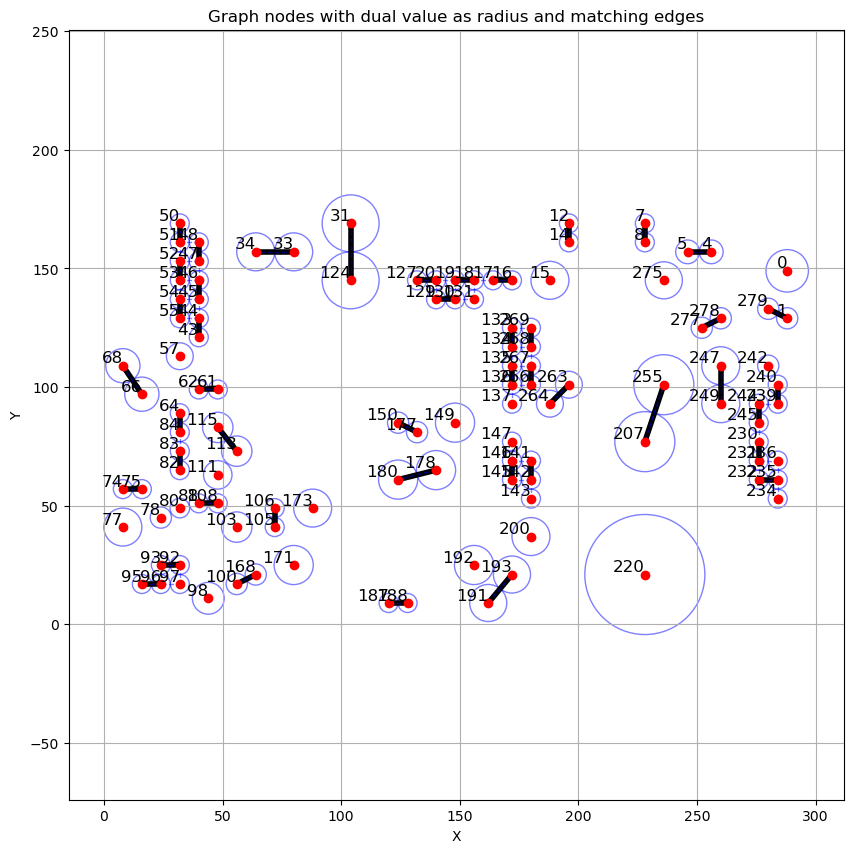

In [35]:
visualize(f,points)

In [36]:
def printnodes():
    for x in f.nodes:
        if x.root == None:
            if x.Matching == None:
                print("Id : ",x.Id, x.Matching,"\n    Root : ", x.root,"\n    Label : ", x.Label, "\n    path: ", [ y.Id for y in x.path])
            else:
                print("Id : ",x.Id, x.Matching.Id,"\n    Root : ", x.root,"\n    Label : ", x.Label, "\n    path: ", [ y.Id for y in x.path])
        else:
            if x.Matching == None:
                print("Id : ",x.Id, x.Matching,"\n    Root : ", x.root.Id,"\n    Label : ", x.Label, "\n    path: ", [ y.Id for y in x.path])
            else:
                print("Id : ",x.Id, x.Matching.Id,"\n    Root : ", x.root.Id,"\n    Label : ", x.Label, "\n    path: ", [ y.Id for y in x.path])

In [37]:
def bfsall():
    unmatchingnode = [node for node in f.nodes if node.Matching == None]
    for x in unmatchingnode:
        if x.Matching != None:
            continue
        f.bfs(x)

In [38]:
while 1:
    bfsall()
    if f.updatedual() == None:
        break


root id :  0
curnode :  0
tight nodes :  []
root id :  15
curnode :  15
tight nodes :  []
root id :  57
curnode :  57
tight nodes :  []
root id :  77
curnode :  77
tight nodes :  []
root id :  78
curnode :  78
tight nodes :  []
root id :  80
curnode :  80
tight nodes :  []
root id :  97
curnode :  97
tight nodes :  [92, 96]
grow 92
grow 96
curnode :  93
tight nodes :  [92, 96]
shrink
======SHRINK==========
97, 96, 93, 92, ======================
0 1 outside
0 4 outside
0 5 outside
0 7 outside
0 8 outside
0 12 outside
0 14 outside
0 15 outside
0 16 outside
0 17 outside
0 18 outside
0 19 outside
0 20 outside
0 31 outside
0 33 outside
0 34 outside
0 43 outside
0 44 outside
0 45 outside
0 46 outside
0 47 outside
0 48 outside
0 50 outside
0 51 outside
0 52 outside
0 53 outside
0 54 outside
0 55 outside
0 57 outside
0 61 outside
0 62 outside
0 64 outside
0 66 outside
0 68 outside
0 74 outside
0 75 outside
0 77 outside
0 78 outside
0 80 outside
0 82 outside
0 83 outside
0 84 outside
0 88 outsi

TypeError: cannot unpack non-iterable NoneType object

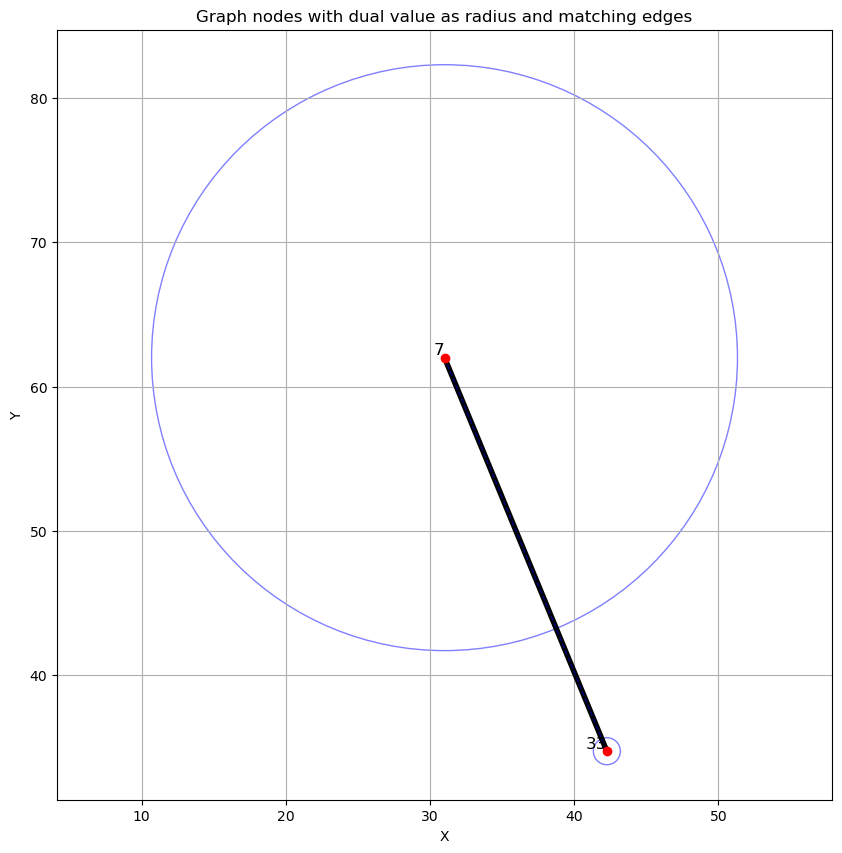

In [14]:
visualize(f,points)

In [ ]:
nextroot = f.updatedual()
f.bfs(nextroot)
visualize(f,points)
nextroot = f.updatedual()
visualize(f,points)
printnodes()



In [ ]:
f.bfs(nextroot)
visualize(f,points)
nextroot = f.updatedual()
visualize(f,points)
printnodes()

In [ ]:
f.bfs(nextroot)
visualize(f,points)
nextroot = f.updatedual()
visualize(f,points)
printnodes()

In [ ]:
f.bfs(nextroot)
visualize(f,points)
nextroot = f.updatedual()
visualize(f,points)
printnodes()

In [ ]:
f.bfs(nextroot)
visualize(f,points)
nextroot = f.updatedual()
visualize(f,points)
printnodes()

In [ ]:
# x = [node for node in f.nodes if node.is_blossom()][0]
# f.EXPAND(x)
# visualize(f,points)

In [ ]:
f.bfs(nextroot)
visualize(f,points)
nextroot = f.updatedual()
visualize(f,points)
printnodes()

In [ ]:
f.bfs(nextroot)
visualize(f,points)
nextroot = f.updatedual()
visualize(f,points)
printnodes()

In [ ]:
f.bfs(nextroot)
visualize(f,points)
nextroot = f.updatedual()
visualize(f,points)
printnodes()

In [ ]:
f.bfs(nextroot)
visualize(f,points)
nextroot = f.updatedual()
visualize(f,points)
printnodes()

In [ ]:
f.bfs(nextroot)
visualize(f,points)
nextroot = f.updatedual()
visualize(f,points)
printnodes()

In [ ]:
f.bfs(nextroot)
visualize(f,points)
nextroot = f.updatedual()
visualize(f,points)
printnodes()

In [ ]:
blossom = None
for node in f.nodes:
    if node.is_blossom():
        blossom = node
        break
if blossom != None:
    f.EXPAND(blossom)
    visualize(f,points)

In [ ]:
blossom = None
for node in f.nodes:
    if node.is_blossom():
        blossom = node
        break
if blossom != None:
    f.EXPAND(blossom)
    visualize(f,points)

In [ ]:
blossom = None
for node in f.nodes:
    if node.is_blossom():
        blossom = node
        break
if blossom != None:
    f.EXPAND(blossom)
    visualize(f,points)

In [ ]:
blossom = None
for node in f.nodes:
    if node.is_blossom():
        blossom = node
        break
if blossom != None:
    f.EXPAND(blossom)
    visualize(f,points)